# **Telecom X - Análisis de Evasión de Clientes**

En el proyecto "Churn de Clientes" de la empresa Telecom X, se analiza la evasión de clientes con el objetivo de identificar los factores que inciden en la cancelación de servicios. Un asistente de análisis de datos participa en la recolección, procesamiento y análisis de información utilizando Python y sus principales bibliotecas. Los hallazgos obtenidos servirán como base para que el equipo de ciencia de datos desarrolle modelos predictivos y estrategias de retención.

###Importación de las librerias Python necesarias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import math

#📌 **1 Extracción**

###1.1 Carga de datos

In [ ]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()


###1.2 Conversión de los datos en un DataFrame

In [ ]:
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 **2 Transformación**

## 2.1 Descripción de columnas y parámetros

####Diccionario de datos
- `customerID` : número de identificación único de cada cliente
- `Churn` : si el cliente dejó o no la empresa
- `gender` : género (masculino y femenino)
- `SeniorCitizen` : información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner` : si el cliente tiene o no una pareja
- `Dependents` : si el cliente tiene o no dependientes
- `tenure` : meses de contrato del cliente
- `PhoneService` : suscripción al servicio telefónico
- `MultipleLines` : suscripción a más de una línea telefónica
- `InternetService` : suscripción a un proveedor de internet
- `OnlineSecurity` : suscripción adicional de seguridad en línea
- `OnlineBackup` : suscripción adicional de respaldo en línea
- `DeviceProtection` : suscripción adicional de protección del dispositivo
- `TechSupport` : suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV` : suscripción de televisión por cable
- `StreamingMovies` : suscripción de streaming de películas
- `Contract` : tipo de contrato
- `PaperlessBilling` : si el cliente prefiere recibir la factura en línea
- `PaymentMethod` : forma de pago
- `Charges.Monthly` : total de todos los servicios del cliente por mes
- `Charges.Total` : total gastado por el cliente

###2.2 Exploración de las columnas del Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [ ]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


## 2.3 Expanción de las columnas con diccionarios como datos

In [ ]:
#Extraccion de datos de columnas con diccionarios

df_customer = pd.json_normalize(df['customer'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])
df_phone = pd.json_normalize(df['phone'])

In [ ]:
df = pd.concat([df, df_customer, df_internet, df_account, df_phone], axis=1)

In [ ]:
datos_expandidos = df.drop(['customer', 'internet', 'account', 'phone'], axis=1)

In [ ]:
datos_expandidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   InternetService   7267 non-null   object 
 8   OnlineSecurity    7267 non-null   object 
 9   OnlineBackup      7267 non-null   object 
 10  DeviceProtection  7267 non-null   object 
 11  TechSupport       7267 non-null   object 
 12  StreamingTV       7267 non-null   object 
 13  StreamingMovies   7267 non-null   object 
 14  Contract          7267 non-null   object 
 15  PaperlessBilling  7267 non-null   object 
 16  PaymentMethod     7267 non-null   object 


In [ ]:
datos_expandidos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,PhoneService,MultipleLines
0,0002-ORFBO,No,Female,0,Yes,Yes,9,DSL,No,Yes,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,Yes,No
1,0003-MKNFE,No,Male,0,No,No,9,DSL,No,No,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,Yes,Yes
2,0004-TLHLJ,Yes,Male,0,No,No,4,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,Yes,No
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes,No
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Fiber optic,No,No,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,Yes,No


In [ ]:
datos_expandidos.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
InternetService,object
OnlineSecurity,object
OnlineBackup,object


## 2.4 Verificación de posibles problemas con los datos

In [ ]:
# Verificación de la existencia de datos nulos

datos_expandidos.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
# Verificación existencia de valores duplicados
datos_expandidos.duplicated().sum()

np.int64(0)

In [ ]:
# Verificación existencia de datos faltantes
datos_expandidos.isna().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
datos_faltantes = datos_expandidos['Charges.Total'].isna()
datos_expandidos[datos_faltantes]


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,PhoneService,MultipleLines


In [ ]:
datos_expandidos = datos_expandidos.dropna(subset=['Charges.Total'])
datos_expandidos

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,PhoneService,MultipleLines
0,0002-ORFBO,No,Female,0,Yes,Yes,9,DSL,No,Yes,...,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,Yes,No
1,0003-MKNFE,No,Male,0,No,No,9,DSL,No,No,...,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,Yes,Yes
2,0004-TLHLJ,Yes,Male,0,No,No,4,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,Yes,No
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,Yes,No
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Fiber optic,No,No,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0151-ONTOV,Yes,Female,0,No,No,1,Fiber optic,No,No,...,No,No,No,Month-to-month,No,Mailed check,70.90,70.90,Yes,No
96,0154-QYHJU,,Male,0,No,No,29,DSL,Yes,Yes,...,Yes,No,No,One year,Yes,Electronic check,58.75,1696.20,Yes,No
97,0156-FVPTA,Yes,Male,0,Yes,No,22,DSL,Yes,No,...,Yes,No,No,Month-to-month,Yes,Electronic check,54.20,1152.70,Yes,No
98,0162-RZGMZ,,Female,1,No,No,5,DSL,Yes,Yes,...,Yes,No,No,Month-to-month,No,Credit card (automatic),59.90,287.85,Yes,No


In [ ]:
# Verificación del formato de la columna con datos de tipo 'float'

datos_expandidos['Charges.Total'] = (
    datos_expandidos['Charges.Total']
    .astype(str)
    .str.replace(' ', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .replace('', None)
    .astype(float)
)

In [ ]:
datos_expandidos['Charges.Total'].dtype

dtype('float64')

In [ ]:
# Verificación de que cada cliente este identificado con una ID
datos_expandidos['customerID'].isnull().sum()

np.int64(0)

In [ ]:
# Mostrar la cantidad de 'abandonos' entre los clientes

datos_expandidos['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [ ]:
# Eliminación de los clientes donde no está difinido el 'Churn'

datos_expandidos = datos_expandidos[datos_expandidos['Churn'] != '']

datos_expandidos['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [ ]:
# Determinación de la cantidad de tarifas que pagan los clientes

datos_expandidos['Charges.Monthly'].unique()

array([65.6 , 59.9 , 73.9 , ..., 91.75, 68.8 , 67.85])

In [ ]:
# Creación de la columna 'Cuentas_diarias'

datos_expandidos['Charges.Daily'] = datos_expandidos['Charges.Monthly'] / 30

In [ ]:
# Verificación de la existencia de la columna 'Charges.Daily'

datos_expandidos.head(1)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,PhoneService,MultipleLines,Charges.Daily
0,0002-ORFBO,No,Female,0,Yes,Yes,9,DSL,No,Yes,...,Yes,No,One year,Yes,Mailed check,65.6,593.3,Yes,No,2.186667


In [ ]:
# Verificación de las columnas del dataset

datos_expandidos.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total', 'PhoneService', 'MultipleLines',
       'Charges.Daily'],
      dtype='object')

In [ ]:
# Conversión de los valores de columnas Object 'Yes' o 'No' en valores binarios 1 y 0

valores_binarios = [
    'Churn', 'Partner', 'Dependents', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling', 'PhoneService', 'MultipleLines'
]

datos_expandidos[valores_binarios] = datos_expandidos[valores_binarios].replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_152/2069474740.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos_expandidos[valores_binarios] = datos_expandidos[valores_binarios].replace({'Yes': 1, 'No': 0})


In [ ]:
# Verificación del cambio de datos 'yes' 'no' en 1 y 0

datos_expandidos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,PhoneService,MultipleLines,Charges.Daily
0,0002-ORFBO,0,Female,0,1,1,9,DSL,0,1,...,1,0,One year,1,Mailed check,65.6,593.30,1,0,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,DSL,0,0,...,0,1,Month-to-month,0,Mailed check,59.9,542.40,1,1,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,Fiber optic,0,0,...,0,0,Month-to-month,1,Electronic check,73.9,280.85,1,0,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,Fiber optic,0,1,...,1,1,Month-to-month,1,Electronic check,98.0,1237.85,1,0,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,Fiber optic,0,0,...,1,0,Month-to-month,1,Mailed check,83.9,267.40,1,0,2.796667


In [ ]:
# Cambio de los nombres de las columnas del diccionario al español para mejor entendimiento

columnas = []
columnas = datos_expandidos.columns
columnas

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total', 'PhoneService', 'MultipleLines',
       'Charges.Daily'],
      dtype='object')

In [ ]:
# Diccionario con los nombres modificados

columnas_en_espanol = {
    'customerID': 'id_cliente',
    'Churn': 'churn',
    'gender': 'genero',
    'SeniorCitizen': 'adulto_mayor',
    'Partner': 'pareja',
    'Dependents': 'dependientes',
    'tenure': 'meses_contrato',
    'InternetService': 'servicio_internet',
    'OnlineSecurity': 'seguridad_en_linea',
    'OnlineBackup': 'respaldo_en_linea',
    'DeviceProtection': 'proteccion_dispositivo',
    'TechSupport': 'soporte_tecnico',
    'StreamingTV': 'tv_streaming',
    'StreamingMovies': 'peliculas_streaming',
    'Contract': 'tipo_contrato',
    'PaperlessBilling': 'factura_electronica',
    'PaymentMethod': 'metodo_pago',
    'Charges.Monthly': 'cargo_mensual',
    'Charges.Total': 'cargo_total',
    'PhoneService': 'servicio_telefonico',
    'MultipleLines': 'multiples_lineas',
    'Charges.Daily': 'cargo_diario'
}

# Renombrado de las columnas
datos_expandidos = datos_expandidos.rename(columns=columnas_en_espanol)

In [ ]:

# Verificación de nuevos nombres de columnas

datos_expandidos.head(1)

,id_cliente,churn,genero,adulto_mayor,pareja,dependientes,meses_contrato,servicio_internet,seguridad_en_linea,respaldo_en_linea,...,tv_streaming,peliculas_streaming,tipo_contrato,factura_electronica,metodo_pago,cargo_mensual,cargo_total,servicio_telefonico,multiples_lineas,cargo_diario
0,0002-ORFBO,0,Female,0,1,1,9,DSL,0,1,...,1,0,One year,1,Mailed check,65.6,593.3,1,0,2.186667


In [ ]:
# Traducción de los valores al españos

datos_expandidos['genero'] = datos_expandidos['genero'].replace({'Female': 'Femenino', 'Male': 'Masculino'})
datos_expandidos['servicio_internet'] = datos_expandidos['servicio_internet'].replace({'Fiber optic': 'Fibra Óptica', 'DSL': 'DSL', 'No': 'No'})
datos_expandidos['tipo_contrato'] = datos_expandidos['tipo_contrato'].replace({'Month-to-month': 'Mensual', 'One year': 'Anual', 'Two year': 'Doble Anual'})
datos_expandidos['metodo_pago'] = datos_expandidos['metodo_pago'].replace({'Electronic check': 'Cheque Electrónico', 'Mailed check': 'Cheque Postal', 'Bank transfer (automatic)': 'Transferencia Bancaria Automática', 'Credit card (automatic)': 'Tarjeta de Crédito Automática'})

# Verificación de los cambios

datos_expandidos.head(10)

,id_cliente,churn,genero,adulto_mayor,pareja,dependientes,meses_contrato,servicio_internet,seguridad_en_linea,respaldo_en_linea,...,tv_streaming,peliculas_streaming,tipo_contrato,factura_electronica,metodo_pago,cargo_mensual,cargo_total,servicio_telefonico,multiples_lineas,cargo_diario
0,0002-ORFBO,0,Femenino,0,1,1,9,DSL,0,1,...,1,0,Anual,1,Cheque Postal,65.60,593.30,1,0,2.186667
1,0003-MKNFE,0,Masculino,0,0,0,9,DSL,0,0,...,0,1,Mensual,0,Cheque Postal,59.90,542.40,1,1,1.996667
2,0004-TLHLJ,1,Masculino,0,0,0,4,Fibra Óptica,0,0,...,0,0,Mensual,1,Cheque Electrónico,73.90,280.85,1,0,2.463333
3,0011-IGKFF,1,Masculino,1,1,0,13,Fibra Óptica,0,1,...,1,1,Mensual,1,Cheque Electrónico,98.00,1237.85,1,0,3.266667
4,0013-EXCHZ,1,Femenino,1,1,0,3,Fibra Óptica,0,0,...,1,0,Mensual,1,Cheque Postal,83.90,267.40,1,0,2.796667
5,0013-MHZWF,0,Femenino,0,0,1,9,DSL,0,0,...,1,1,Mensual,1,Tarjeta de Crédito Automática,69.40,571.45,1,0,2.313333
6,0013-SMEOE,0,Femenino,1,1,0,71,Fibra Óptica,1,1,...,1,1,Doble Anual,1,Transferencia Bancaria Automática,109.70,7904.25,1,0,3.656667
7,0014-BMAQU,0,Masculino,0,1,0,63,Fibra Óptica,1,0,...,0,0,Doble Anual,1,Tarjeta de Crédito Automática,84.65,5377.80,1,1,2.821667
8,0015-UOCOJ,0,Femenino,1,0,0,7,DSL,1,0,...,0,0,Mensual,1,Cheque Electrónico,48.20,340.35,1,0,1.606667
9,0016-QLJIS,0,Femenino,0,1,1,65,DSL,1,1,...,1,1,Doble Anual,1,Cheque Postal,90.45,5957.90,1,1,3.015000


In [ ]:
# Identificación de los métodos de pago

datos_expandidos['metodo_pago'].unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

## Carga y Análisis

In [ ]:
datos_expandidos.describe()

,churn,adulto_mayor,pareja,dependientes,meses_contrato,factura_electronica,cargo_mensual,cargo_total,servicio_telefonico,cargo_diario
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.592719,64.798208,2283.300441,0.903299,2.159940
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.491363,30.085974,2266.771362,0.295571,1.002866
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.250000,18.800000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,35.587500,401.450000,1.000000,1.186250
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,70.350000,1397.475000,1.000000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,89.862500,3794.737500,1.000000,2.995417
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,118.750000,8684.800000,1.000000,3.958333


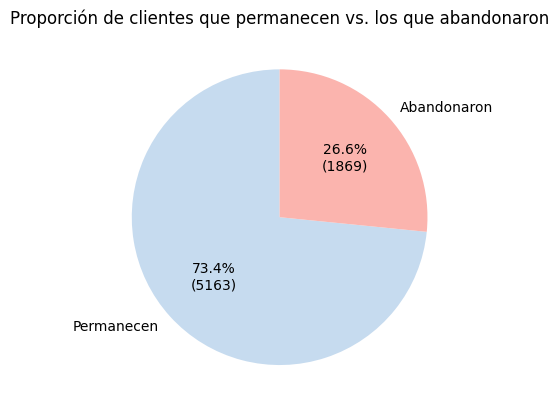

In [ ]:
# Contar valores
conteo = datos_expandidos['churn'].value_counts()

# Etiquetas personalizadas
labels = ['Permanecen', 'Abandonaron']

colores = ['#C6DBEF', '#FBB4AE']

# Crear gráfico de torta
plt.figure()

plt.pie(conteo,
        labels=labels,
        colors=colores,
        autopct=lambda p: f'{p:.1f}%\n({int(p * sum(conteo) / 100)})',
        startangle=90)

plt.title('Proporción de clientes que permanecen vs. los que abandonaron')

plt.show()

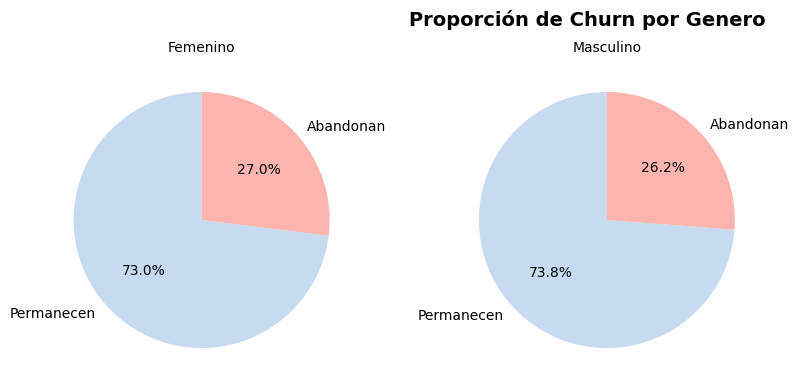

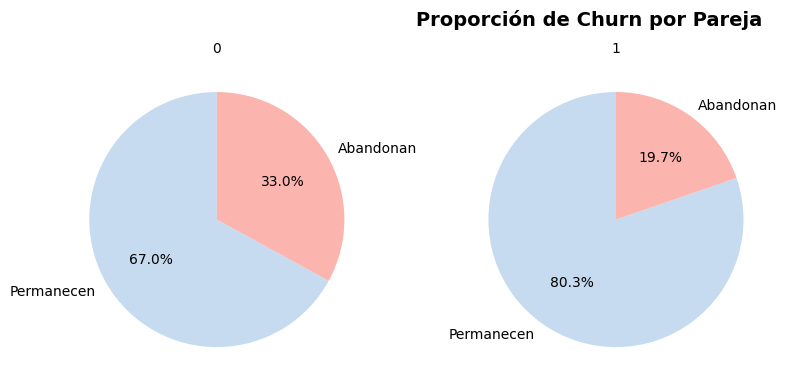

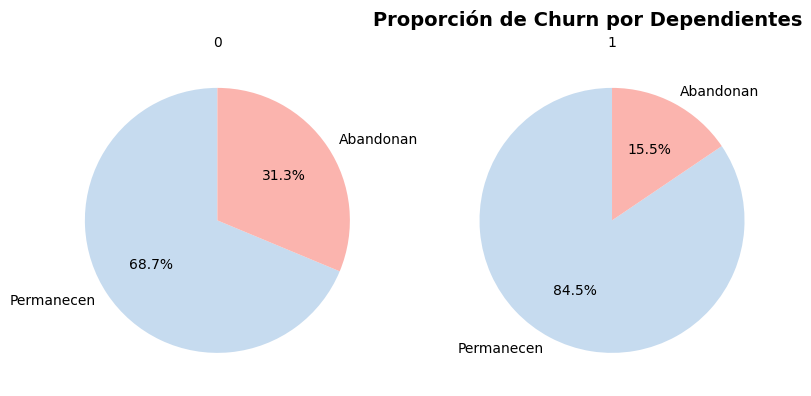

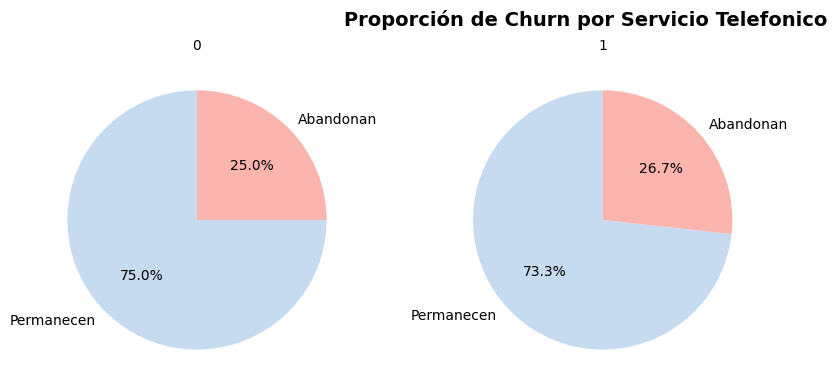

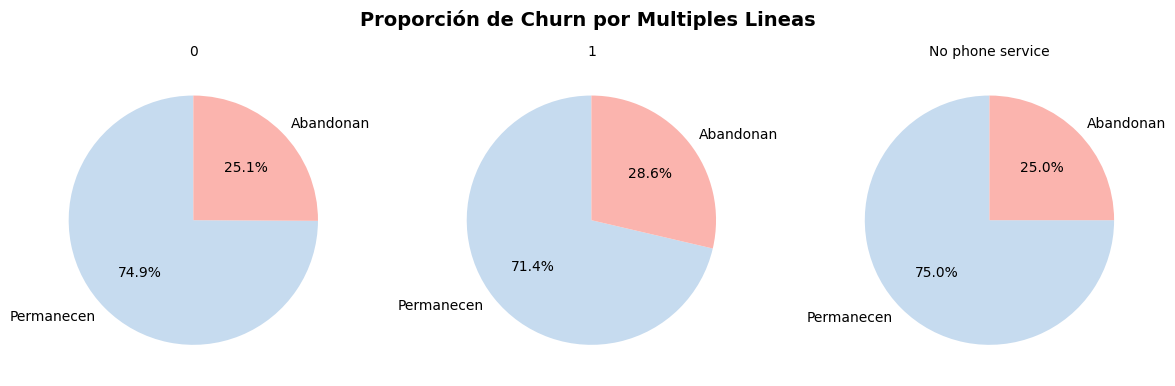

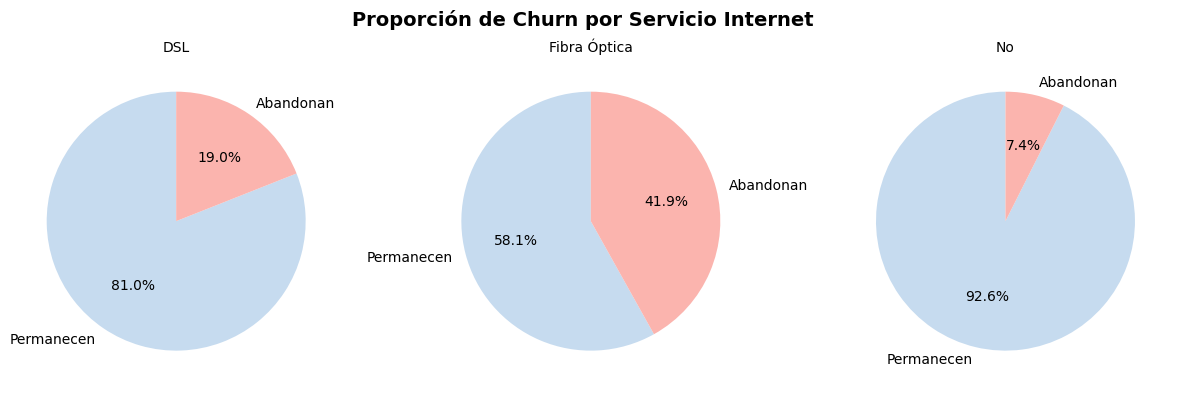

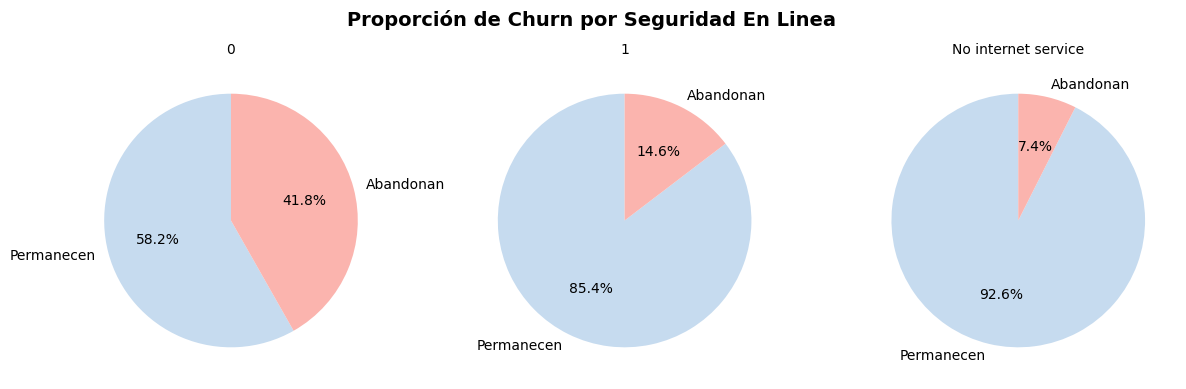

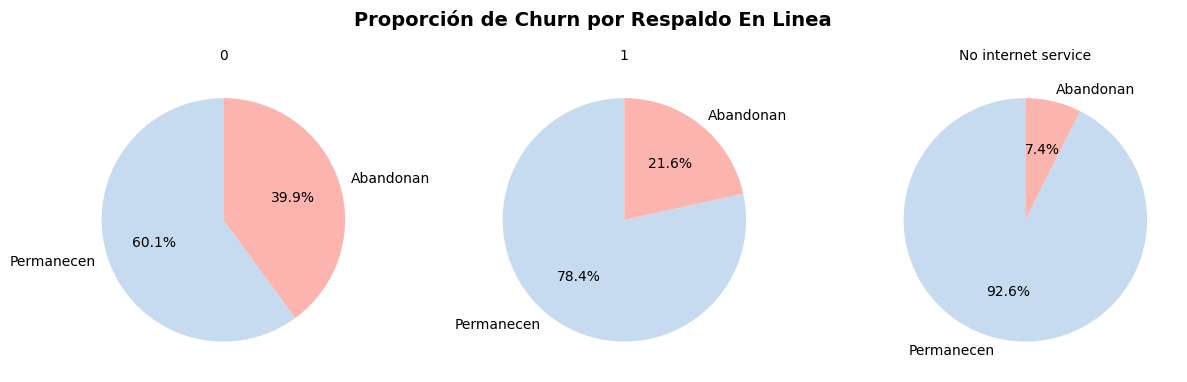

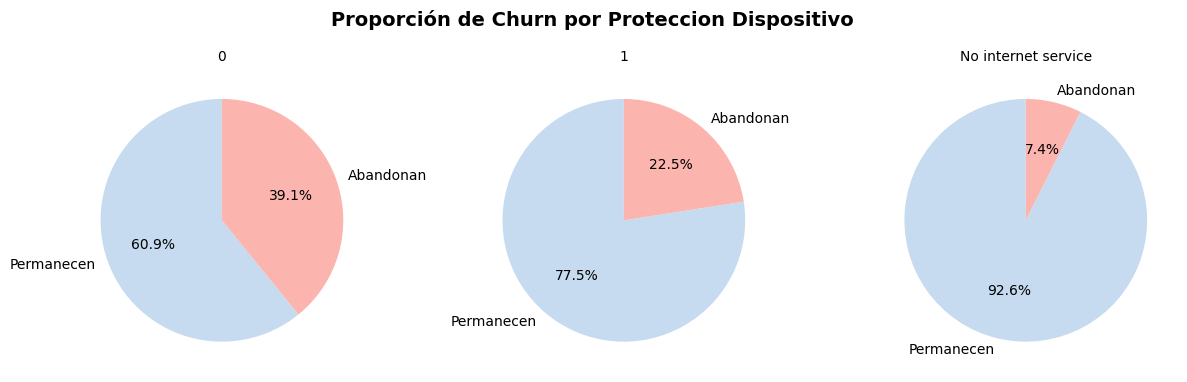

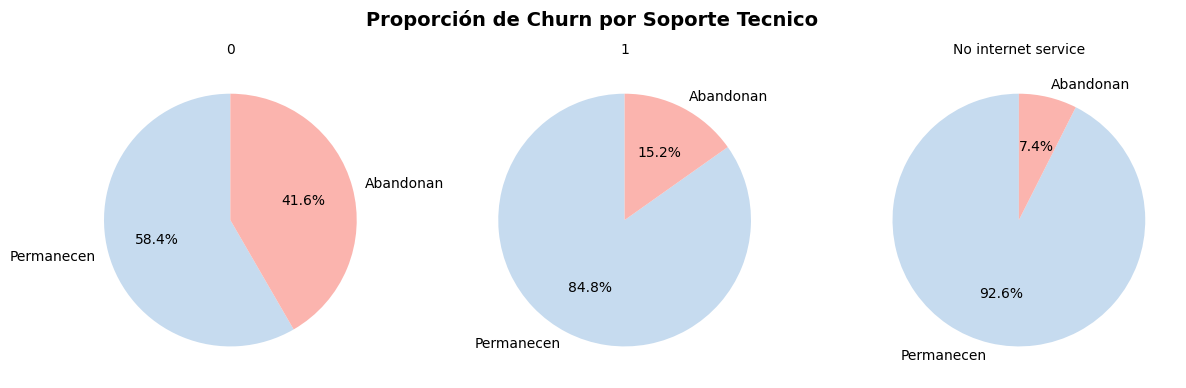

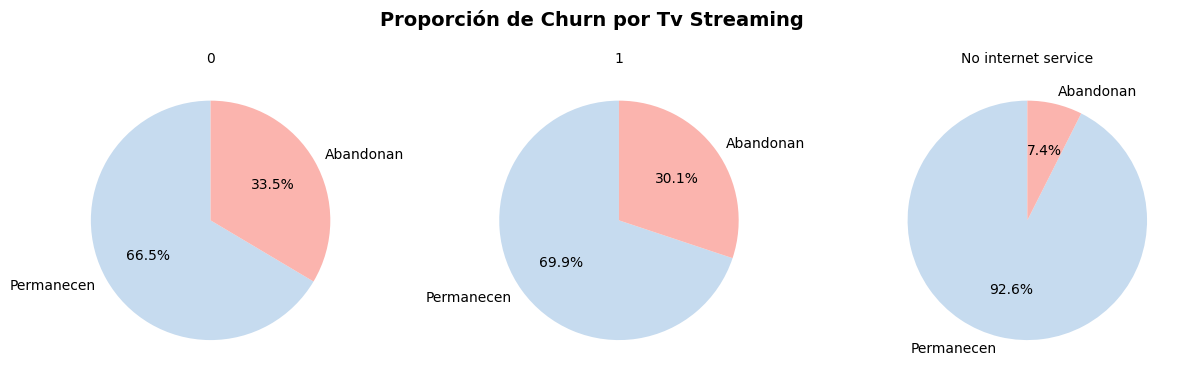

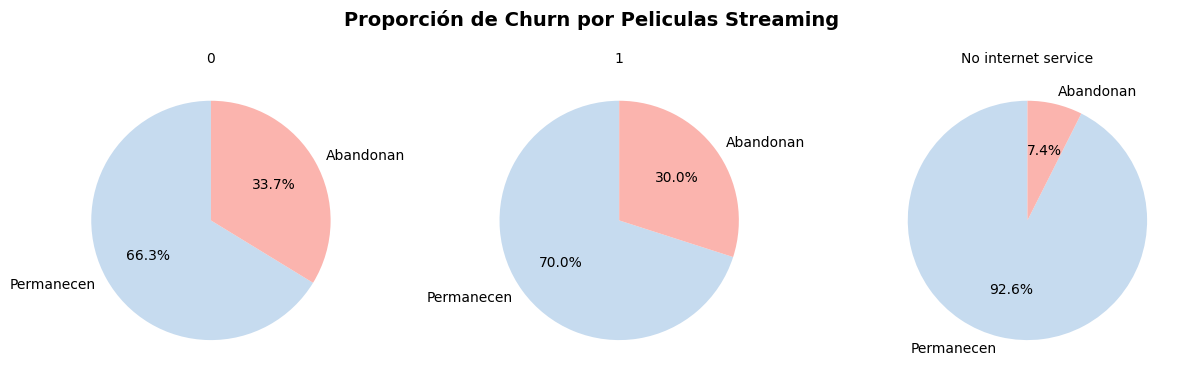

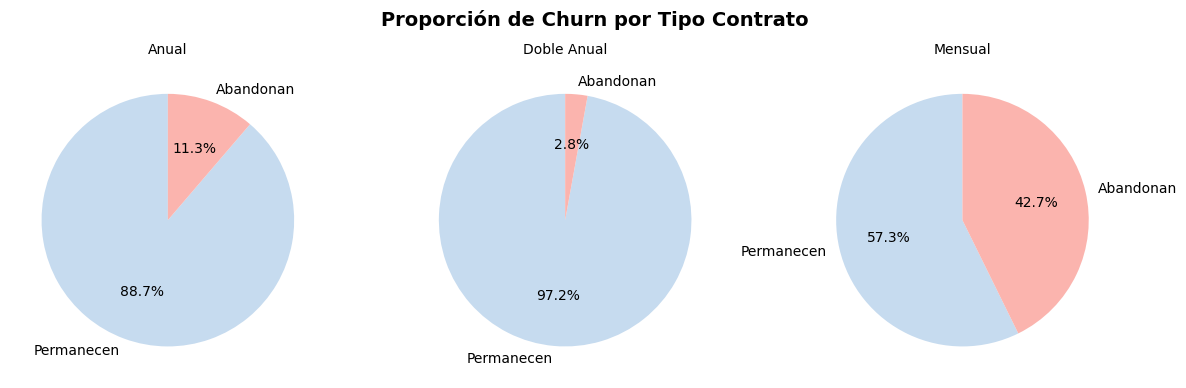

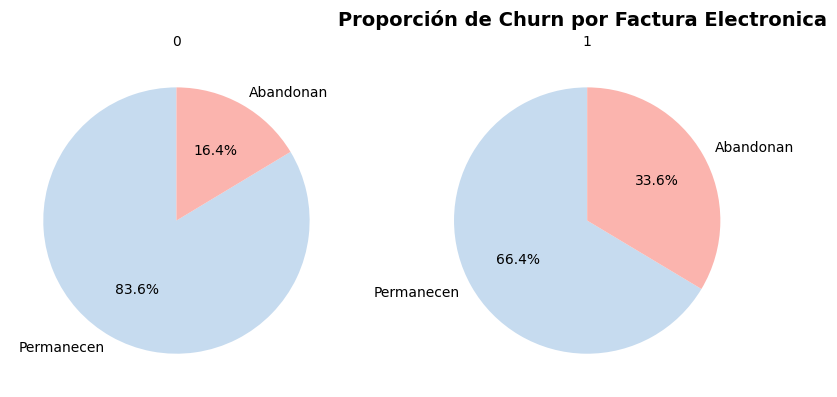

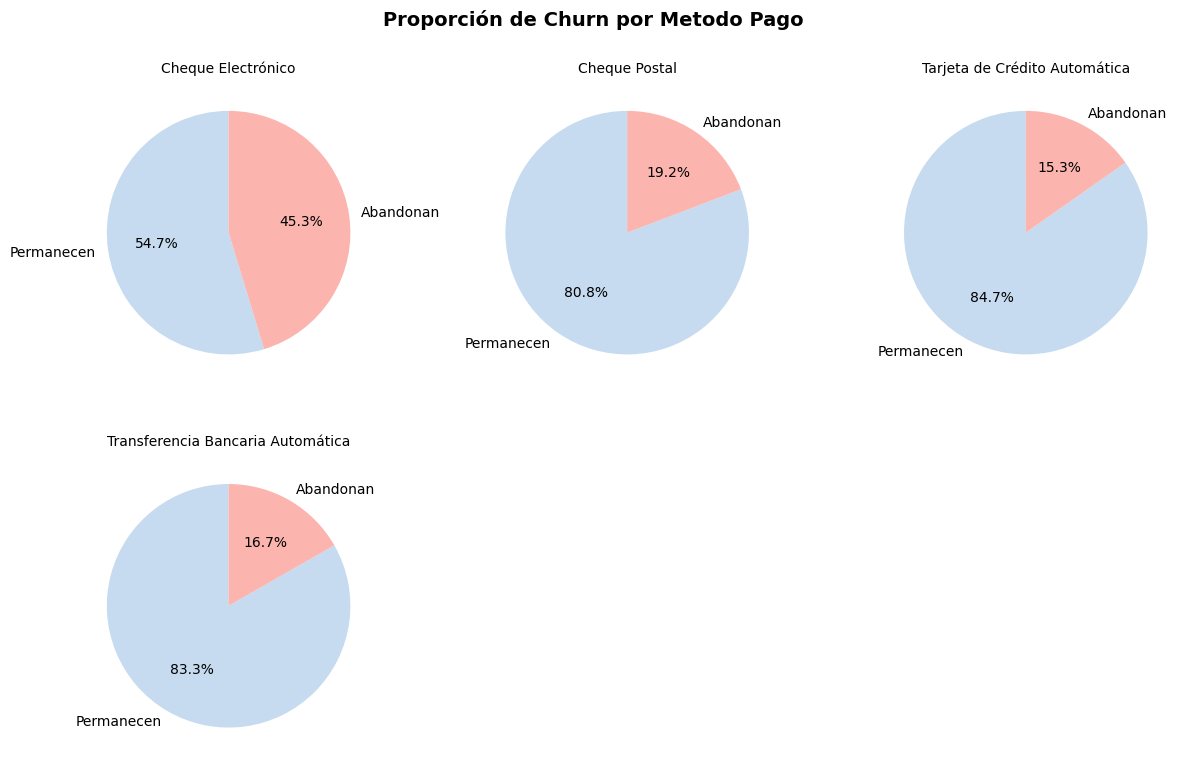

In [ ]:
variables_categoricas = [
    'genero', 'pareja', 'dependientes', 'servicio_telefonico',
    'multiples_lineas', 'servicio_internet', 'seguridad_en_linea',
    'respaldo_en_linea', 'proteccion_dispositivo', 'soporte_tecnico',
    'tv_streaming', 'peliculas_streaming', 'tipo_contrato',
    'factura_electronica', 'metodo_pago'
]

colores = ['#C6DBEF', '#FBB4AE']  # azul pastel claro, rojo pastel claro

for col in variables_categoricas:

    proporciones = (
        datos_expandidos
        .groupby(col)['churn']
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
    )

    categorias = proporciones.index
    n = len(categorias)

    columnas = 3
    filas = math.ceil(n / columnas)

    fig, axes = plt.subplots(filas, columnas, figsize=(columnas*4, filas*4))
    axes = axes.flatten()  # Facilita iteración

    for i, categoria in enumerate(categorias):

        valores = proporciones.loc[categoria]

        axes[i].pie(
            valores,
            labels=['Permanecen', 'Abandonan'],
            colors=colores,
            autopct='%1.1f%%',
            startangle=90
        )

        axes[i].set_title(f'{categoria}', fontsize=10)

    # Eliminar ejes vacíos si sobran espacios
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(
        f'Proporción de Churn por {col.replace("_", " ").title()}',
        fontsize=14,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

## Conteo evasion de variables numericas  

In [ ]:
# Muestra de las columnas numéricas

columnas_numericas = ['meses_contrato', 'cargo_mensual', 'cargo_total', 'cargo_diario']

/tmp/ipykernel_152/2335434877.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


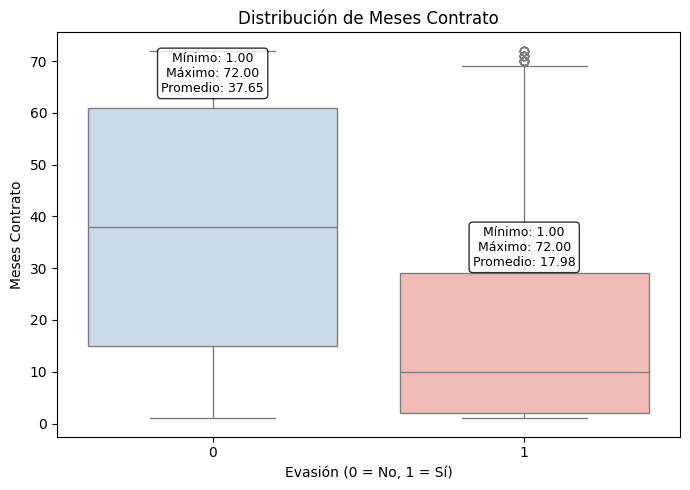

/tmp/ipykernel_152/2335434877.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


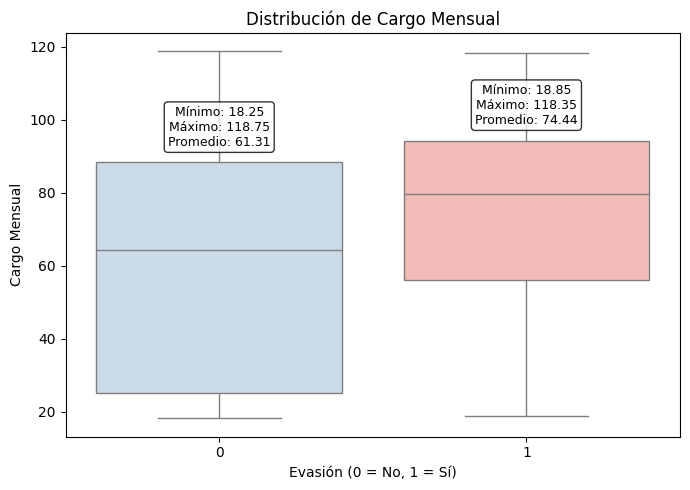

/tmp/ipykernel_152/2335434877.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


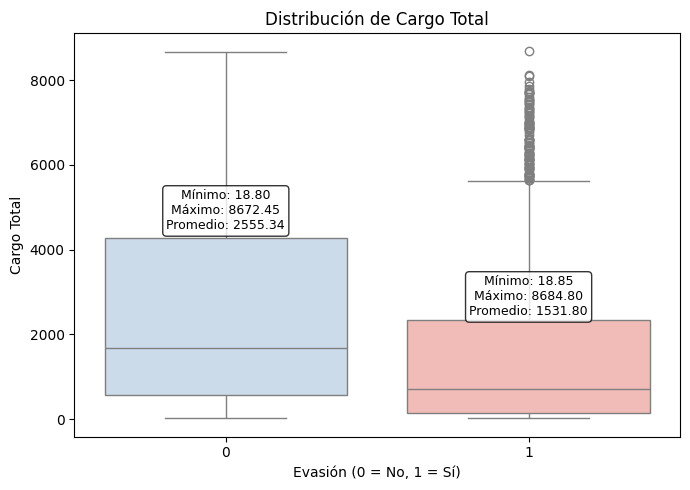

/tmp/ipykernel_152/2335434877.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


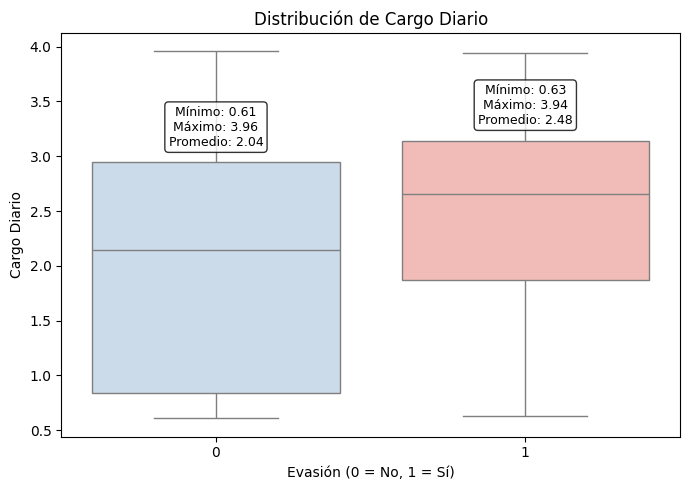

In [ ]:
for col in columnas_numericas:
    plt.figure(figsize=(7, 5))

    ax = sns.boxplot(
        x='churn',
        y=col,
        data=datos_expandidos,
        palette={'0': '#C6DBEF', '1': '#FBB4AE'}
    )

    plt.title(f'Distribución de {col.replace("_", " ").title()}')
    plt.ylabel(col.replace("_", " ").title())
    plt.xlabel('Evasión (0 = No, 1 = Sí)')

    # Agregar etiquetas para mejor claridad
    for grupo in datos_expandidos['churn'].unique():

        datos = datos_expandidos[datos_expandidos['churn'] == grupo][col].dropna()

        minimo = datos.min()
        maximo = datos.max()
        promedio = datos.mean()
        q3 = datos.quantile(0.75)

        x_pos = grupo
        y_pos = q3 + (q3 * 0.05)

        etiqueta = (
            f'Mínimo: {minimo:.2f}\n'
            f'Máximo: {maximo:.2f}\n'
            f'Promedio: {promedio:.2f}'
        )

        ax.text(
            x=x_pos,
            y=y_pos,
            s=etiqueta,
            ha='center',
            fontsize=9,
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round')
        )

    plt.tight_layout()
    plt.show()

# Tarea Extra

## Analisis de correlacion entre variables

In [ ]:
# Relación entre la cuenta diaria y la evasión

correlacion = datos_expandidos['churn'].corr(datos_expandidos['cargo_diario'])
print(f'La correlación entre la cuenta diaria y la evasión es: {correlacion}')

La correlación entre la cuenta diaria y la evasión es: 0.19285821847007872


/tmp/ipykernel_152/3895318901.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='cargo_diario', data=datos_expandidos, palette={'0': '#C6DBEF', '1': '#FBB4AE'})


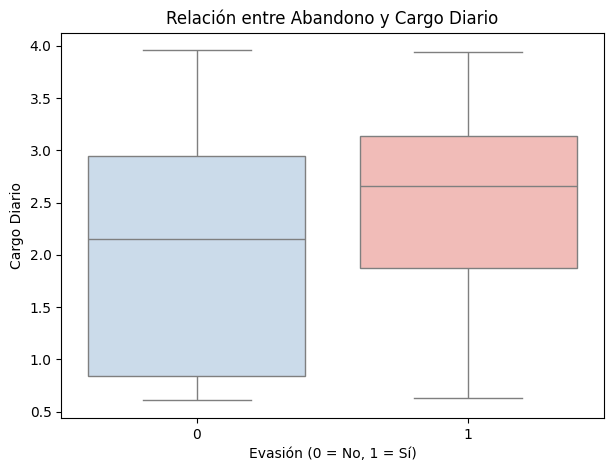

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(
    x='churn',
    y='cargo_diario',
    data=datos_expandidos,
    palette={'0': '#C6DBEF', '1': '#FBB4AE'}
)

plt.title('Relación entre Abandono y Cargo Diario')
plt.ylabel('Cargo Diario')
plt.xlabel('Evasión (0 = No, 1 = Sí)')

plt.show()

In [ ]:
datos_expandidos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              7032 non-null   object 
 1   churn                   7032 non-null   int64  
 2   genero                  7032 non-null   object 
 3   adulto_mayor            7032 non-null   int64  
 4   pareja                  7032 non-null   int64  
 5   dependientes            7032 non-null   int64  
 6   meses_contrato          7032 non-null   int64  
 7   servicio_internet       7032 non-null   object 
 8   seguridad_en_linea      7032 non-null   object 
 9   respaldo_en_linea       7032 non-null   object 
 10  proteccion_dispositivo  7032 non-null   object 
 11  soporte_tecnico         7032 non-null   object 
 12  tv_streaming            7032 non-null   object 
 13  peliculas_streaming     7032 non-null   object 
 14  tipo_contrato           7032 non-null   objec

In [ ]:
columnas_numericas = [
    'churn',               # abandono
    'meses_contrato',
    'cargo_mensual',
    'cargo_total',
    'cargo_diario',
    'adulto_mayor',        # binaria (0 = no adulto mayor, 1 = si adulto mayor)
    'pareja',              # 0 y 1
    'dependientes',        # 0 y 1
]

## Muestra de las correlaciones de las variables con el abandono (Churn)

In [ ]:
correlaciones = datos_expandidos[columnas_numericas].corr()
print(correlaciones['churn'].sort_values(ascending=False))

churn             1.000000
cargo_diario      0.192858
cargo_mensual     0.192858
adulto_mayor      0.150541
pareja           -0.149982
dependientes     -0.163128
cargo_total      -0.199484
meses_contrato   -0.354049
Name: churn, dtype: float64


## Mapa de correlaciones entre las variables

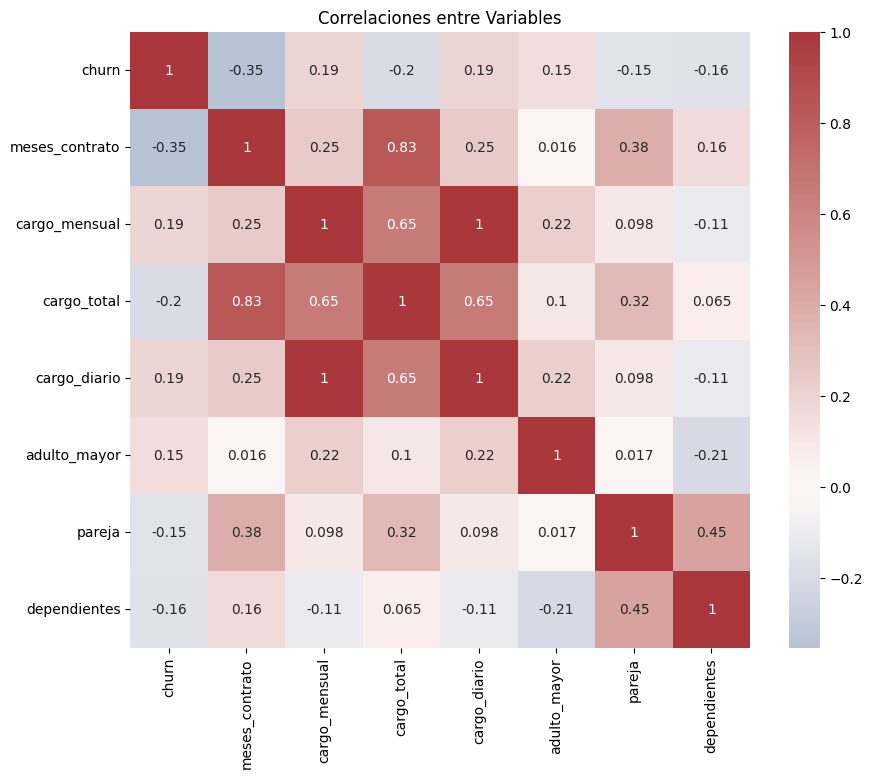

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlaciones,
    annot=True,
    cmap='vlag',
    center=0
)

plt.title('Correlaciones entre Variables')
plt.show()

/tmp/ipykernel_152/527140619.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


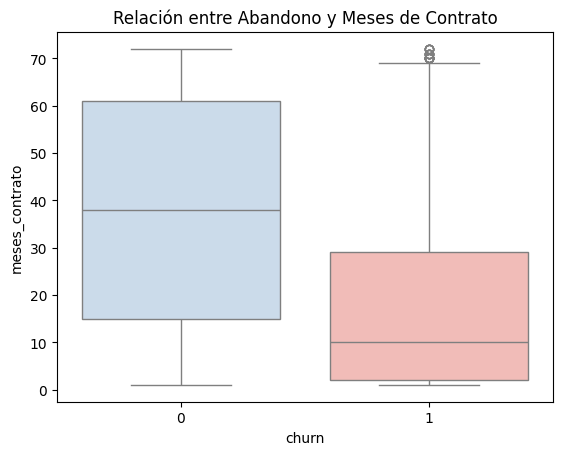

In [ ]:
sns.boxplot(
    x='churn',
    y='meses_contrato',
    data=datos_expandidos,
    palette={'0': '#C6DBEF', '1': '#FBB4AE'}
)
plt.title('Relación entre Abandono y Meses de Contrato')

plt.show()

# Informe Final

El presente informe se enmarca en el proyecto "Churn de Clientes" de Telecom X, una empresa que actualmente enfrenta una preocupante tasa de cancelaciones por parte de sus clientes. El objetivo principal de este análisis es comprender los factores que influyen en la evasión, con el fin de aportar información estratégica que permita diseñar acciones concretas para mejorar la retención de clientes. Como asistente en el área de análisis de datos, tu labor ha sido fundamental en la importación, tratamiento y exploración de los datos mediante el uso de Python y bibliotecas como Pandas, Matplotlib y Seaborn. El proyecto se desarrolló siguiendo principios de un proceso ETL (Extracción, Transformación y Carga) para garantizar datos limpios y estructurados. A través de un Análisis Exploratorio de Datos (EDA) se identificaron patrones, correlaciones y posibles indicadores de riesgo de abandono. Este informe presenta los hallazgos clave del análisis, que servirán de base para la futura implementación de modelos predictivos de churn.

5.2. Limpieza y Tratamiento de Datos

El primer paso fue asegurar la calidad de los datos antes de analizarlos. Para ello, se realizó una limpieza exhaustiva de los datos brutos disponibles en formato JSON. Esta etapa incluyó:

Eliminación de valores nulos: se identificaron columnas con datos ausentes, especialmente en cargo_total, y se eliminaron filas incompletas para mantener la consistencia del análisis. Ver celda de tratamiento de nulos.
Conversión de tipos de datos: muchas columnas con valores binarios (Yes/No) estaban en formato object. Estas fueron transformadas a int64 para permitir cálculos y visualizaciones. Esto incluyó variables como pareja, servicio_telefonico, factura_electronica, entre otras.
Normalización de nombres de columnas: se renombraron todas las columnas a español con formato estandarizado (minúsculas, guión bajo), lo cual facilitó la interpretación y manejo del DataFrame.
Creación de nuevas variables: se generaron columnas como cargo_diario, derivada del cargo_mensual, y cantidad_servicios, que suma el total de servicios contratados por cliente. Estas variables se diseñaron para ofrecer mejores perspectivas analíticas.
Esta etapa fue clave para estructurar correctamente el dataset y preparar las variables relevantes para el análisis posterior.

5.3. Análisis Exploratorio de Datos

Una vez preparados los datos, se realizó un análisis exploratorio para comprender los factores relacionados con la evasión de clientes (churn). A través de visualizaciones y métricas estadísticas, se observaron los siguientes patrones clave:

Distribución de evasión: mediante un gráfico de barras, se visualizó que aproximadamente un cuarto de los clientes abandonan el servicio, lo que representa una tasa importante de churn.
Relación con variables categóricas: se analizaron variables como tipo de contrato, servicios adicionales, forma de pago y presencia de dependientes. Se utilizaron gráficos apilados para observar cómo varía la evasión dentro de cada categoría.
Relación con variables numéricas: se emplearon boxplots y correlaciones para analizar el vínculo entre el churn y variables como meses_contrato, cargo_mensual, cargo_total y cantidad_servicios. Se observó que los clientes con contratos más largos y mayor número de servicios contratados tienden a permanecer, mientras que quienes pagan más mensualmente o tienen pocos servicios presentan mayor propensión a abandonar.
Análisis de correlaciones: se construyó una matriz de calor para observar la fuerza de la relación entre variables. meses_contrato tuvo la correlación más fuerte y negativa con churn, indicando que clientes con más tiempo suelen quedarse.
Estas observaciones permiten generar hipótesis y comprender el perfil del cliente propenso a abandonar, lo cual es esencial para diseñar estrategias de retención.

5.4 Conclusiones

El análisis permitió extraer varias conclusiones importantes respecto al comportamiento de los clientes de Telecom X:

Tiempo con la empresa: los clientes con mayor antigüedad (meses_contrato) muestran una clara tendencia a permanecer, lo que sugiere que las estrategias de fidelización temprana podrían ser efectivas para reducir el churn.
Carga económica: un cargo_mensual más elevado está levemente asociado con mayor evasión. Esto puede deberse a la percepción de alto costo, lo que indica la necesidad de revisar precios o mejorar el valor percibido.
Compromiso con el servicio: los usuarios que contratan más servicios (cantidad_servicios) abandonan menos, lo que sugiere que promover paquetes integrados puede aumentar la retención.
Factores personales: los clientes con pareja o dependientes tienen menor tendencia al abandono, lo cual puede indicar un uso más compartido y necesidad de continuidad del servicio.

5.5. Recomendaciones

Siguientes pasos recomendados:

Construir un modelo predictivo de churn usando las variables más influyentes identificadas.
Diseñar campañas dirigidas a clientes con riesgo de evasión, como los que tienen pocos servicios o contratos mensuales.
Explorar mejoras en el onboarding de nuevos clientes para convertirlos en usuarios de largo plazo.
Este análisis constituye una base sólida para avanzar en estrategias más sofisticadas basadas en datos, orientadas a mejorar la fidelización y reducir la pérdida de clientes en Telecom X. ¿Te gustaría que prepare también una celda final con resumen automático de correlaciones clave o una tabla